# BÁO CÁO THỰC NGHIỆM GIỮA KỲ - XỬ LÝ TÍN HIỆU SỐ
## THUẬT TOÁN 3 (TT3): PHÂN ĐOẠN TIẾNG NÓI VÀ KHOẢNG LẶNG (VAD) DỰA TRÊN PHÂN BỐ GAUSS CỦA NĂNG LƯỢNG NGẮN HẠN (STE)

- **Sinh viên thực hiện**: [Họ và Tên Sinh Viên]  
- **Mã số sinh viên (MSSV)**: [Mã Số Sinh Viên]  
- **Lớp / Khóa**: Xử lý Tín hiệu Số - Kỳ 2026  
- **Nhiệm vụ được giao**:
  1. Tự cài đặt các hàm DSP cơ sở (framing: 25ms, hop 10ms, STE chuẩn hóa, lọc khoảng lặng ảo < 200ms) bằng Python/Numpy thuần.
  2. Khảo sát toàn bộ các khung speech và silence trên 04 tín hiệu huấn luyện (*.lab) để tìm phân bố dữ liệu ($mean_{Sp}, std_{Sp}, mean_{Sil}, std_{Sil}$).
  3. Dựa vào 2 phân bố dữ liệu Gauss để giải phương trình xác suất Bayes tìm ngưỡng STE phân biệt tối ưu dùng chung $T_{opt}$.
  4. Đánh giá thực nghiệm định lượng (MAE, RMSE ms) và trực quan (4 figures) trên tập tín hiệu kiểm thử.

### 1. Cấu hình môi trường và nạp các thư viện toán học cơ sở
Khai báo các thư viện chuẩn của Python (`wave`, `math`, `os`, `glob`) và thư viện tính toán ma trận `numpy`, thư viện vẽ đồ thị `matplotlib`.

In [1]:
import os
import glob
import math
import wave
from pathlib import Path
from typing import Tuple, List, Dict, Any

import numpy as np
import matplotlib.pyplot as plt

# Cấu hình kích thước và kiểu hiển thị đồ thị chuẩn báo cáo học thuật
plt.rcParams.update({
    "font.size": 10,
    "figure.titlesize": 12,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.grid": True,
    "grid.alpha": 0.4,
    "grid.linestyle": ":"
})
print("Môi trường thực thi đã sẵn sàng.")

Môi trường thực thi đã sẵn sàng.


### 2. Thiết lập đường dẫn thư mục dữ liệu dự án
Xác định vị trí các thư mục `TinHieuHuanLuyen`, `TinHieuKiemThu` và thư mục lưu trữ kết quả đầu ra.

In [2]:
def find_project_root() -> Path:
    curr = Path.cwd()
    for candidate in [curr, *curr.parents]:
        if (candidate / "TinHieuHuanLuyen").exists() and (candidate / "TinHieuKiemThu").exists():
            return candidate
    raise FileNotFoundError("Không tìm thấy thư mục gốc của dự án.")

PROJECT_ROOT = find_project_root()
TRAIN_DIR = PROJECT_ROOT / "TinHieuHuanLuyen"
TEST_DIR = PROJECT_ROOT / "TinHieuKiemThu"
OUTPUT_DIR = PROJECT_ROOT / "TT3" / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Thư mục huấn luyện : {TRAIN_DIR}")
print(f"Thư mục kiểm thử   : {TEST_DIR}")
print(f"Thư mục xuất ảnh   : {OUTPUT_DIR}")

Thư mục huấn luyện : /home/bim/Projects/DSP_MidTerm/TinHieuHuanLuyen
Thư mục kiểm thử   : /home/bim/Projects/DSP_MidTerm/TinHieuKiemThu
Thư mục xuất ảnh   : /home/bim/Projects/DSP_MidTerm/TT3/output


### 3. Đọc dữ liệu âm thanh từ file WAV (PCM 16-bit)
Sử dụng thư viện `wave` chuẩn của Python để giải mã luồng byte sang mảng mẫu số nguyên 16-bit và chuẩn hóa biên độ về khoảng `[-1.0, 1.0]`.

In [3]:
def read_wav(file_path: str) -> Tuple[np.ndarray, int]:
    """Đọc file âm thanh WAV chuẩn 16-bit PCM sử dụng thư viện wave tích hợp sẵn."""
    with wave.open(file_path, "rb") as wf:
        n_channels = wf.getnchannels()
        sample_width = wf.getsampwidth()
        sample_rate = wf.getframerate()
        n_frames = wf.getnframes()
        raw_bytes = wf.readframes(n_frames)

    if sample_width != 2:
        raise ValueError(f"Chỉ hỗ trợ file WAV 16-bit PCM (sample_width=2), hiện tại: {sample_width}")

    audio_int16 = np.frombuffer(raw_bytes, dtype=np.int16)
    if n_channels > 1:
        audio_int16 = audio_int16.reshape(-1, n_channels).mean(axis=1).astype(np.int16)

    signal = audio_int16.astype(np.float64) / 32768.0
    return signal, sample_rate

print("Hàm read_wav đã được định nghĩa.")

Hàm read_wav đã được định nghĩa.


### 4. Đọc file nhãn Praat .lab và trích xuất mốc tiếng nói chuẩn (Ground Truth)
Bóc tách các mốc thời gian từ file `.lab`, xác định điểm bắt đầu và kết thúc của câu nói dựa trên các nhãn `v` (voiced) hoặc `uv` (unvoiced).

In [4]:
def read_lab(lab_path: str) -> List[Tuple[float, float, str]]:
    """Đọc và phân tích file nhãn mốc thời gian phân đoạn (.lab) của Praat."""
    segments: List[Tuple[float, float, str]] = []
    with open(lab_path, "r", encoding="utf-8") as f:
        for line in f:
            stripped = line.strip()
            if not stripped:
                continue
            parts = stripped.split()
            if len(parts) >= 3 and parts[0] not in ("F0mean", "F0std"):
                try:
                    segments.append((float(parts[0]), float(parts[1]), parts[2].lower()))
                except ValueError:
                    continue
    return segments


def get_speech_groundtruth(lab_segments: List[Tuple[float, float, str]]) -> Tuple[float, float]:
    """Xác định mốc bắt đầu và kết thúc toàn bộ câu nói chuẩn từ danh sách các đoạn nhãn."""
    speech_segments = [seg for seg in lab_segments if seg[2] in ("v", "uv")]
    if not speech_segments:
        return 0.0, 0.0
    t_start = min(seg[0] for seg in speech_segments)
    t_end = max(seg[1] for seg in speech_segments)
    return t_start, t_end

print("Hàm read_lab và get_speech_groundtruth đã được định nghĩa.")

Hàm read_lab và get_speech_groundtruth đã được định nghĩa.


### 5. Tự cài đặt hàm phân khung tín hiệu (Signal Framing)
Chia tín hiệu 1D thành các khung có độ dài 25 ms với bước nhảy 10 ms, tính toán mốc thời gian trung tâm của mỗi khung.

In [5]:
def frame_signal(
    signal: np.ndarray,
    sample_rate: int,
    frame_size_ms: float = 25.0,
    hop_size_ms: float = 10.0
) -> Tuple[np.ndarray, np.ndarray]:
    """Phân chia tín hiệu âm thanh thành các khung (frames) chồng lấp bằng chỉ số Numpy cơ bản."""
    frame_len = int(round(frame_size_ms * sample_rate / 1000.0))
    hop_len = int(round(hop_size_ms * sample_rate / 1000.0))

    num_samples = len(signal)
    if num_samples < frame_len:
        pad_len = frame_len - num_samples
        padded = np.zeros(frame_len, dtype=signal.dtype)
        padded[:num_samples] = signal
        signal = padded
        num_samples = len(signal)

    num_frames = 1 + int(np.floor((num_samples - frame_len) / hop_len))
    frames = np.zeros((num_frames, frame_len), dtype=np.float64)
    frame_times = np.zeros(num_frames, dtype=np.float64)

    for m in range(num_frames):
        start_idx = m * hop_len
        end_idx = start_idx + frame_len
        frames[m, :] = signal[start_idx:end_idx]
        frame_times[m] = (start_idx + end_idx) / (2.0 * sample_rate)

    return frames, frame_times

print("Hàm frame_signal đã được định nghĩa.")

Hàm frame_signal đã được định nghĩa.


### 6. Tính toán Năng lượng ngắn hạn (Short-Time Energy - STE) chuẩn hóa
Tính tổng bình phương các mẫu trong từng khung theo công thức: $STE[m] = \sum_{n=0}^{N-1} x^2[m \cdot H + n]$, sau đó chuẩn hóa về $[0.0, 1.0]$.

In [6]:
def compute_ste(frames: np.ndarray) -> np.ndarray:
    """Tính năng lượng ngắn hạn (STE) bằng tổng bình phương biên độ mẫu trong khung."""
    squared_frames = np.square(frames)
    return np.sum(squared_frames, axis=1)


def normalize_ste(ste: np.ndarray) -> np.ndarray:
    """Chuẩn hóa vector năng lượng ngắn hạn về đoạn [0.0, 1.0]."""
    max_energy = np.max(ste)
    if max_energy <= 1e-12:
        return np.zeros_like(ste)
    return ste / max_energy


def extract_ste_features(
    signal: np.ndarray,
    sample_rate: int,
    frame_size_ms: float = 25.0,
    hop_size_ms: float = 10.0
) -> Tuple[np.ndarray, np.ndarray]:
    """Quy trình tích hợp: Phân khung (25ms, hop 10ms) -> Tính STE -> Chuẩn hóa STE về [0, 1]."""
    frames, frame_times = frame_signal(signal, sample_rate, frame_size_ms, hop_size_ms)
    ste_raw = compute_ste(frames)
    ste_norm = normalize_ste(ste_raw)
    return ste_norm, frame_times

print("Các hàm trích xuất đặc trưng STE đã được định nghĩa.")

Các hàm trích xuất đặc trưng STE đã được định nghĩa.


## SLIDE 2: KHẢO SÁT DỮ LIỆU HUẤN LUYỆN (TRAINING DATA SURVEY)
Khảo sát tất cả các speech frames và silence frames trong 04 file huấn luyện (`phone_F1`, `phone_M1`, `studio_F1`, `studio_M1`) dựa vào mốc thời gian trong file `.lab`.

In [7]:
def survey_training_data(training_dir: str, frame_size_ms: float = 25.0, hop_size_ms: float = 10.0):
    """Khảo sát toàn bộ các khung tín hiệu trên 4 file huấn luyện, phân chia thành silence và speech."""
    wav_files = sorted(glob.glob(os.path.join(training_dir, "*.wav")))
    all_silence_ste: List[float] = []
    all_speech_ste: List[float] = []
    per_file_stats: Dict[str, Dict[str, float]] = {}

    for wav_path in wav_files:
        fname = os.path.basename(wav_path)
        lab_path = os.path.splitext(wav_path)[0] + ".lab"
        signal, sample_rate = read_wav(wav_path)
        ste_norm, frame_times = extract_ste_features(signal, sample_rate, frame_size_ms, hop_size_ms)
        lab_segments = read_lab(lab_path)
        gt_start, gt_end = get_speech_groundtruth(lab_segments)

        file_silence, file_speech = [], []
        for t, energy in zip(frame_times, ste_norm):
            if gt_start <= t <= gt_end:
                file_speech.append(float(energy))
            else:
                file_silence.append(float(energy))

        all_silence_ste.extend(file_silence)
        all_speech_ste.extend(file_speech)

        per_file_stats[fname] = {
            "mean_sil": float(np.mean(file_silence)),
            "std_sil": float(np.std(file_silence)),
            "mean_sp": float(np.mean(file_speech)),
            "std_sp": float(np.std(file_speech)),
            "num_sil": len(file_silence),
            "num_sp": len(file_speech)
        }

    return np.array(all_silence_ste), np.array(all_speech_ste), per_file_stats

silence_ste, speech_ste, per_file_stats = survey_training_data(str(TRAIN_DIR), 25.0, 10.0)
print(f"Tổng số khung khoảng lặng (Silence) khảo sát : {len(silence_ste):,}")
print(f"Tổng số khung tiếng nói (Speech) khảo sát     : {len(speech_ste):,}")

Tổng số khung khoảng lặng (Silence) khảo sát : 497
Tổng số khung tiếng nói (Speech) khảo sát     : 794


## SLIDE 3: THỐNG KÊ PHÂN BỐ GAUSS (meanSil, stdSil, meanSp, stdSp)
Giả sử năng lượng STE chuẩn hóa tuân theo phân bố Gauss: $p(x|\text{sil}) \sim \mathcal{N}(\mu_{sil}, \sigma_{sil}^2)$ và $p(x|\text{sp}) \sim \mathcal{N}(\mu_{sp}, \sigma_{sp}^2)$.

In [8]:
def estimate_gaussian_parameters(silence_ste: np.ndarray, speech_ste: np.ndarray):
    """Tính kỳ vọng (mean) và độ lệch chuẩn (std) của khoảng lặng và tiếng nói bằng hàm Numpy built-in."""
    mu_sil = float(np.mean(silence_ste))
    sigma_sil = float(np.std(silence_ste))
    mu_sp = float(np.mean(speech_ste))
    sigma_sp = float(np.std(speech_ste))
    return mu_sil, sigma_sil, mu_sp, sigma_sp

mu_sil, sigma_sil, mu_sp, sigma_sp = estimate_gaussian_parameters(silence_ste, speech_ste)

print("=" * 82)
print(f"{'Tên file huấn luyện':<18} | {'meanSil':<12} | {'stdSil':<12} | {'meanSp':<12} | {'stdSp':<12}")
print("-" * 82)
for fname, s in per_file_stats.items():
    print(f"{fname:<18} | {s['mean_sil']:<12.6f} | {s['std_sil']:<12.6f} | {s['mean_sp']:<12.6f} | {s['std_sp']:<12.6f}")
print("=" * 82)
print(f"{'GỘP 04 FILE (CHUNG)':<18} | {mu_sil:<12.6f} | {sigma_sil:<12.6f} | {mu_sp:<12.6f} | {sigma_sp:<12.6f}")
print("=" * 82)

Tên file huấn luyện | meanSil      | stdSil       | meanSp       | stdSp       
----------------------------------------------------------------------------------
phone_F1.wav       | 0.000707     | 0.000389     | 0.168980     | 0.227214    
phone_M1.wav       | 0.000963     | 0.001076     | 0.185222     | 0.231091    
studio_F1.wav      | 0.000097     | 0.000484     | 0.325465     | 0.247925    
studio_M1.wav      | 0.000029     | 0.000072     | 0.158558     | 0.193408    
GỘP 04 FILE (CHUNG) | 0.000387     | 0.000709     | 0.202649     | 0.235626    


## SLIDE 4: GIẢI PHƯƠNG TRÌNH BAYES XÁC ĐỊNH NGƯỠNG TỐI ƯU
Tìm ngưỡng phân biệt tối ưu $T_{opt}$ bằng cách giải phương trình phân bố xác suất Gauss Bayes: $p(x|\text{sil}) = p(x|\text{sp})$, tương đương phương trình bậc hai $A x^2 + B x + C = 0$.

In [9]:
def solve_bayes_threshold(mu_sil: float, sigma_sil: float, mu_sp: float, sigma_sp: float) -> float:
    """Giải phương trình giao điểm mật độ xác suất Gauss Bayes: p(x|sil) = p(x|sp)."""
    var_sil = sigma_sil ** 2
    var_sp = sigma_sp ** 2

    coef_a = (1.0 / var_sil) - (1.0 / var_sp)
    coef_b = -2.0 * ((mu_sil / var_sil) - (mu_sp / var_sp))
    coef_c = (mu_sil ** 2 / var_sil) - (mu_sp ** 2 / var_sp) + 2.0 * math.log(sigma_sil / sigma_sp)

    delta = coef_b ** 2 - 4.0 * coef_a * coef_c
    if delta < 0:
        return float((mu_sil * sigma_sp + mu_sp * sigma_sil) / (sigma_sil + sigma_sp))

    sqrt_delta = math.sqrt(delta)
    root1 = (-coef_b + sqrt_delta) / (2.0 * coef_a)
    root2 = (-coef_b - sqrt_delta) / (2.0 * coef_a)

    valid_roots = [r for r in (root1, root2) if mu_sil <= r <= mu_sp]
    if valid_roots:
        return float(valid_roots[0])
    
    positive_roots = [r for r in (root1, root2) if r > 0]
    return float(min(positive_roots, key=lambda r: abs(r - mu_sil)))

T_opt = solve_bayes_threshold(mu_sil, sigma_sil, mu_sp, sigma_sp)
print(f"Hệ số A = {((1.0/sigma_sil**2)-(1.0/sigma_sp**2)):.4f}")
print(f"Hệ số B = {-2.0*((mu_sil/sigma_sil**2)-(mu_sp/sigma_sp**2)):.4f}")
print(f"Hệ số C = {((mu_sil**2/sigma_sil**2)-(mu_sp**2/sigma_sp**2)+2.0*math.log(sigma_sil/sigma_sp)):.4f}")
print()
print(f"=> NGƯỠNG PHÂN BIỆT TỐI ƯU TÌM ĐƯỢC DÙNG CHUNG CHO 04 FILE: T_opt = {T_opt:.6f}")

Hệ số A = 1987714.1189
Hệ số B = -1531.6451
Hệ số C = -12.0533

=> NGƯỠNG PHÂN BIỆT TỐI ƯU TÌM ĐƯỢC DÙNG CHUNG CHO 04 FILE: T_opt = 0.002878


## SLIDE 5: ĐỒ THỊ MINH HỌA PHÂN BỐ GAUSS VÀ NGƯỠNG CẮT PHÂN BIỆT
Vẽ đường cong mật độ phân bố xác suất Gauss lý thuyết của khoảng lặng và tiếng nói, thể hiện rõ giao điểm và ngưỡng phân định $T_{opt}$.

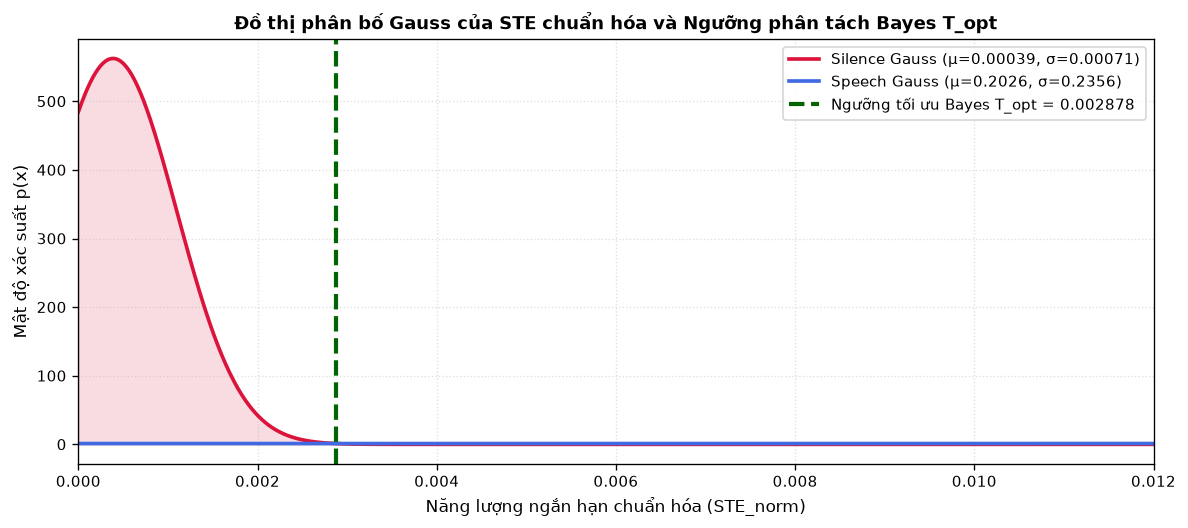

In [10]:
x_range = np.linspace(0.0, 0.015, 2000)

def gaussian_pdf(x, mu, sigma):
    return (1.0 / (sigma * np.sqrt(2.0 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

pdf_silence = gaussian_pdf(x_range, mu_sil, sigma_sil)
pdf_speech = gaussian_pdf(x_range, mu_sp, sigma_sp)

fig, ax = plt.subplots(figsize=(10, 4.5), dpi=120)
ax.plot(x_range, pdf_silence, color="crimson", lw=2.2, label=f"Silence Gauss (μ={mu_sil:.5f}, σ={sigma_sil:.5f})")
ax.plot(x_range, pdf_speech, color="royalblue", lw=2.2, label=f"Speech Gauss (μ={mu_sp:.4f}, σ={sigma_sp:.4f})")

ax.axvline(T_opt, color="darkgreen", linestyle="--", lw=2.5, label=f"Ngưỡng tối ưu Bayes T_opt = {T_opt:.6f}")
ax.fill_between(x_range[x_range <= T_opt], pdf_silence[x_range <= T_opt], color="crimson", alpha=0.15)
ax.fill_between(x_range[x_range >= T_opt], pdf_speech[x_range >= T_opt], color="royalblue", alpha=0.15)

ax.set_title("Đồ thị phân bố Gauss của STE chuẩn hóa và Ngưỡng phân tách Bayes T_opt", fontweight="bold")
ax.set_xlabel("Năng lượng ngắn hạn chuẩn hóa (STE_norm)")
ax.set_ylabel("Mật độ xác suất p(x)")
ax.set_xlim(0.0, 0.012)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

### 7. Phân loại nhị phân và hậu xử lý lọc khoảng lặng ảo ngắn < 200 ms
So sánh năng lượng với ngưỡng $T_{opt}$, lấp đầy các khoảng lặng ảo $< 200\text{ ms}$ (20 khung với bước 10ms) nằm giữa các phân đoạn tiếng nói.

In [11]:
def apply_threshold(ste_norm: np.ndarray, threshold: float) -> np.ndarray:
    """Phân loại nhị phân từng khung: 1 nếu STE >= threshold, ngược lại 0."""
    return (ste_norm >= threshold).astype(np.int32)


def remove_short_silences(
    frame_decisions: np.ndarray,
    hop_size_ms: float = 10.0,
    min_silence_ms: float = 200.0
) -> np.ndarray:
    """Loại bỏ các khoảng lặng ảo < 200 ms (tương ứng 20 khung với hop 10 ms)."""
    min_frames = int(round(min_silence_ms / hop_size_ms))
    smoothed = frame_decisions.copy()
    speech_indices = np.where(smoothed == 1)[0]
    if len(speech_indices) == 0:
        return smoothed

    first_speech, last_speech = speech_indices[0], speech_indices[-1]
    idx = first_speech
    while idx <= last_speech:
        if smoothed[idx] == 0:
            zero_start = idx
            while idx <= last_speech and smoothed[idx] == 0:
                idx += 1
            if (idx - zero_start) < min_frames:
                smoothed[zero_start:idx] = 1
        else:
            idx += 1
    return smoothed


def extract_speech_boundaries(
    frame_decisions: np.ndarray,
    hop_size_ms: float = 10.0,
    frame_size_ms: float = 25.0
) -> Tuple[float, float]:
    """Trích xuất mốc thời gian bắt đầu T_start và kết thúc T_end của câu nói."""
    speech_indices = np.where(frame_decisions == 1)[0]
    if len(speech_indices) == 0:
        return 0.0, 0.0

    start_idx, end_idx = speech_indices[0], speech_indices[-1]
    hop_sec = hop_size_ms / 1000.0
    frame_sec = frame_size_ms / 1000.0

    t_start = round(float(start_idx * hop_sec), 4)
    t_end = round(float(end_idx * hop_sec + frame_sec), 4)
    return t_start, t_end


def predict_vad(
    signal: np.ndarray,
    sample_rate: int,
    threshold: float,
    frame_size_ms: float = 25.0,
    hop_size_ms: float = 10.0
):
    """Chu trình phân đoạn hoàn chỉnh từ tín hiệu thô đến mốc thời gian [T_start, T_end]."""
    ste_norm, frame_times = extract_ste_features(
        signal=signal,
        sample_rate=sample_rate,
        frame_size_ms=frame_size_ms,
        hop_size_ms=hop_size_ms
    )
    raw_decisions = apply_threshold(ste_norm, threshold)
    smoothed = remove_short_silences(raw_decisions, hop_size_ms=hop_size_ms)
    t_start, t_end = extract_speech_boundaries(
        smoothed,
        hop_size_ms=hop_size_ms,
        frame_size_ms=frame_size_ms
    )
    return t_start, t_end, ste_norm, frame_times, smoothed

print("Các hàm xử lý nhị phân và hậu xử lý đã được định nghĩa.")

Các hàm xử lý nhị phân và hậu xử lý đã được định nghĩa.


### 8. Định nghĩa các chỉ số đánh giá sai số định lượng (MAE và RMSE miligiây)
Tính sai số tuyệt đối trung bình (MAE) và sai số bình phương trung bình (RMSE) theo miligiây giữa biên dự đoán và biên chuẩn Ground Truth.

In [12]:
def calculate_mae_rmse(pred_bounds: Tuple[float, float], gt_bounds: Tuple[float, float]) -> Tuple[float, float]:
    """Tính MAE và RMSE (miligiây) theo đúng công thức quy định."""
    pred_start, pred_end = pred_bounds
    gt_start, gt_end = gt_bounds

    diff_start_ms = abs(pred_start - gt_start) * 1000.0
    diff_end_ms = abs(pred_end - gt_end) * 1000.0

    mae_ms = (diff_start_ms + diff_end_ms) / 2.0
    rmse_ms = math.sqrt((diff_start_ms ** 2 + diff_end_ms ** 2) / 2.0)
    return mae_ms, rmse_ms

print("Hàm tính toán sai số MAE/RMSE đã được định nghĩa.")

Hàm tính toán sai số MAE/RMSE đã được định nghĩa.


## SLIDE 6: KẾT QUẢ THỰC NGHIỆM ĐỊNH LƯỢNG TRÊN TẬP KIỂM THỬ (TEST DATA)
Chạy thuật toán TT3 với cấu hình khung 25 ms, hop 10 ms và ngưỡng $T_{opt} = 0.002878$ trên 04 tín hiệu kiểm thử.

In [13]:
test_files = sorted(glob.glob(os.path.join(str(TEST_DIR), "*.wav")))
eval_results = []
test_data_cache = []

for wav_path in test_files:
    fname = os.path.basename(wav_path)
    lab_path = os.path.splitext(wav_path)[0] + ".lab"

    signal, sample_rate = read_wav(wav_path)
    lab_segments = read_lab(lab_path)
    gt_bounds = get_speech_groundtruth(lab_segments)

    pred_start, pred_end, ste_norm, frame_times, smoothed = predict_vad(
        signal=signal,
        sample_rate=sample_rate,
        threshold=T_opt,
        frame_size_ms=25.0,
        hop_size_ms=10.0
    )
    pred_bounds = (pred_start, pred_end)

    mae_ms, rmse_ms = calculate_mae_rmse(pred_bounds, gt_bounds)
    d_start_ms = abs(pred_start - gt_bounds[0]) * 1000.0
    d_end_ms = abs(pred_end - gt_bounds[1]) * 1000.0

    eval_results.append({
        "file": fname,
        "gt": gt_bounds,
        "pred": pred_bounds,
        "d_start": d_start_ms,
        "d_end": d_end_ms,
        "mae": mae_ms,
        "rmse": rmse_ms
    })
    test_data_cache.append((fname, signal, sample_rate, ste_norm, frame_times, gt_bounds, pred_bounds, mae_ms, rmse_ms))

print("=" * 96)
print(f"{'Tên file kiểm thử':<16} | {'GT [s]':<14} | {'Dự đoán [s]':<14} | {'ΔStart (ms)':<11} | {'ΔEnd (ms)':<10} | {'MAE (ms)':<9} | {'RMSE (ms)':<9}")
print("-" * 96)
for r in eval_results:
    gt_str = f"[{r['gt'][0]:.2f}, {r['gt'][1]:.2f}]"
    pred_str = f"[{r['pred'][0]:.2f}, {r['pred'][1]:.2f}]"
    print(f"{r['file']:<16} | {gt_str:<14} | {pred_str:<14} | {r['d_start']:<11.1f} | {r['d_end']:<10.1f} | {r['mae']:<9.1f} | {r['rmse']:<9.1f}")
print("=" * 96)

avg_mae = np.mean([r["mae"] for r in eval_results])
avg_rmse = np.mean([r["rmse"] for r in eval_results])
print(f"[*] SAI SỐ TUYỆT ĐỐI TRUNG BÌNH TOÀN TẬP (AVERAGE MAE) : {avg_mae:.2f} ms")
print(f"[*] SAI SỐ BÌNH PHƯƠNG TRUNG BÌNH TOÀN TẬP (AVERAGE RMSE): {avg_rmse:.2f} ms")
print("=" * 96)

Tên file kiểm thử | GT [s]         | Dự đoán [s]    | ΔStart (ms) | ΔEnd (ms)  | MAE (ms)  | RMSE (ms)
------------------------------------------------------------------------------------------------
phone_F2.wav     | [1.02, 4.04]   | [1.01, 4.08]   | 10.0        | 45.0       | 27.5      | 32.6     
phone_M2.wav     | [0.53, 2.52]   | [0.52, 2.52]   | 10.0        | 5.0        | 7.5       | 7.9      
studio_F2.wav    | [0.77, 2.37]   | [0.76, 2.37]   | 10.0        | 5.0        | 7.5       | 7.9      
studio_M2.wav    | [0.45, 1.93]   | [0.46, 1.94]   | 10.0        | 5.0        | 7.5       | 7.9      
[*] SAI SỐ TUYỆT ĐỐI TRUNG BÌNH TOÀN TẬP (AVERAGE MAE) : 12.50 ms
[*] SAI SỐ BÌNH PHƯƠNG TRUNG BÌNH TOÀN TẬP (AVERAGE RMSE): 14.08 ms


## SLIDE 7: MINH HỌA 04 FIGURE KẾT QUẢ PHÂN ĐOẠN TÍN HIỆU KIỂM THỬ
Mỗi figure bao gồm dạng sóng âm thanh và đặc trưng STE xếp chồng, các đường kẻ dọc màu đỏ biểu diễn biên chuẩn Ground Truth và đường nét đứt màu xanh biểu diễn biên do thuật toán xác định.

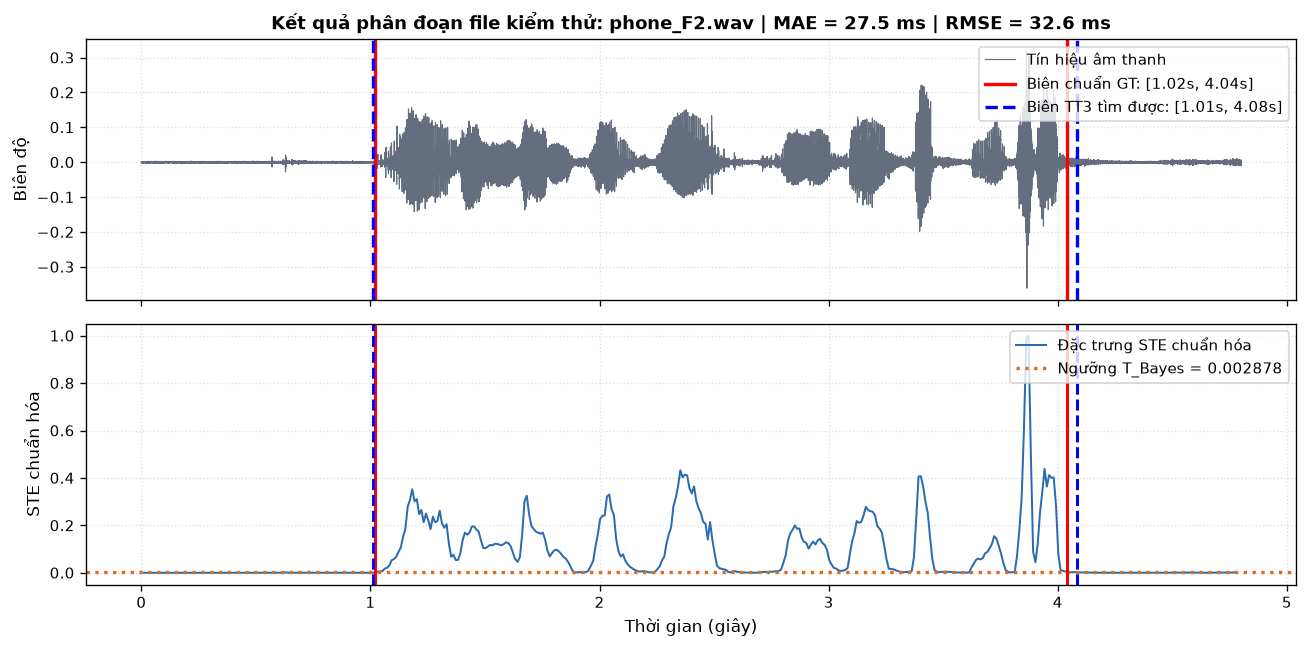

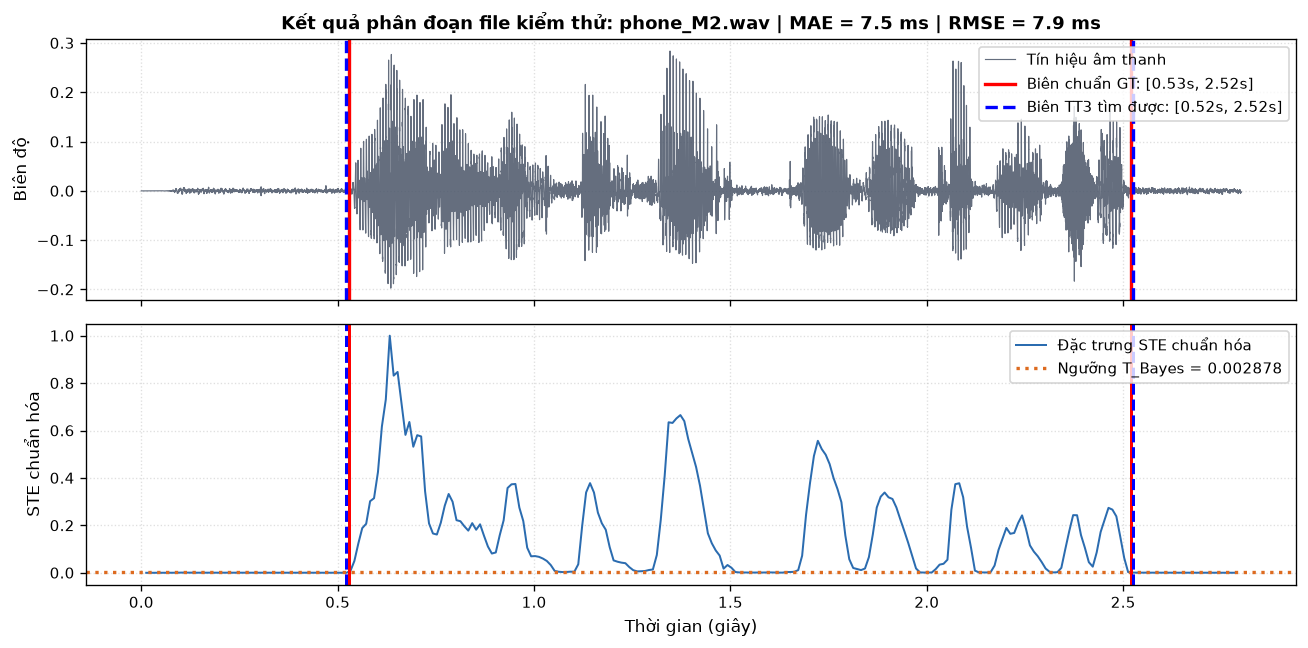

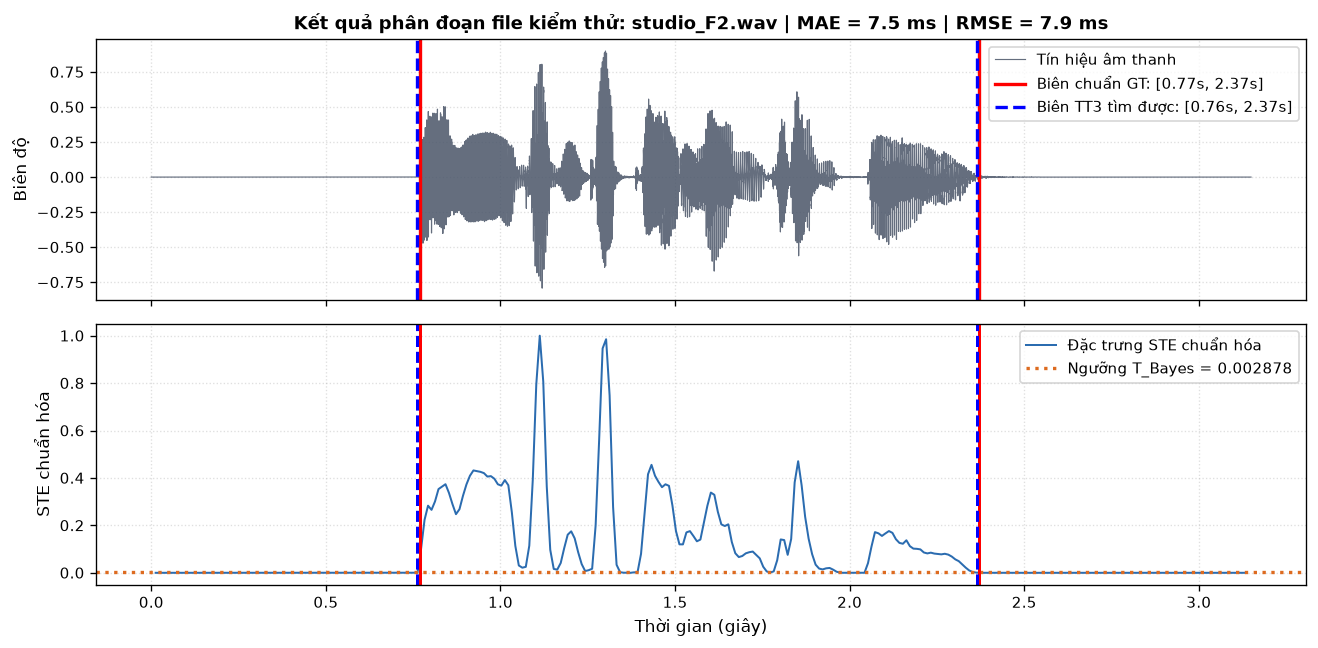

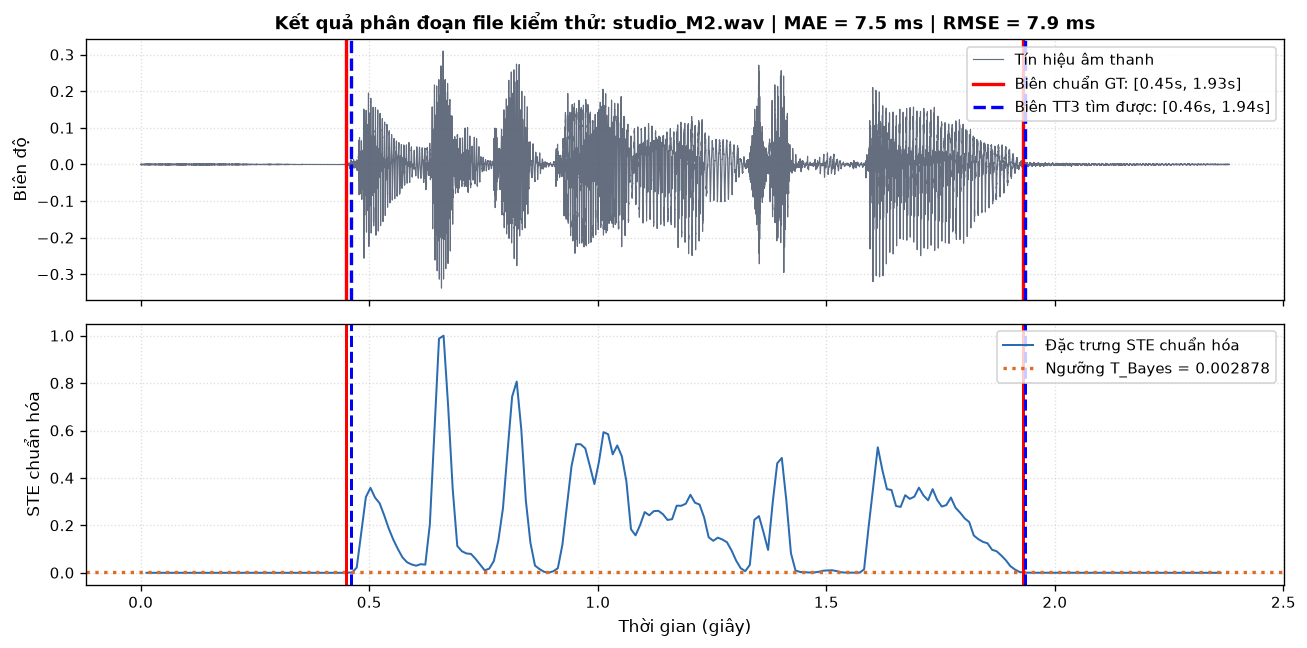

In [14]:
for item in test_data_cache:
    fname, sig, sr, ste, ft, gt, pred, mae, rmse = item
    time_wave = np.arange(len(sig)) / float(sr)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True, dpi=120)

    # Đồ thị con 1: Dạng sóng âm thanh
    ax1.plot(time_wave, sig, color="#4a5568", lw=0.7, alpha=0.85, label="Tín hiệu âm thanh")
    ax1.axvline(gt[0], color="red", linestyle="-", lw=2.0, label=f"Biên chuẩn GT: [{gt[0]:.2f}s, {gt[1]:.2f}s]")
    ax1.axvline(gt[1], color="red", linestyle="-", lw=2.0)
    ax1.axvline(pred[0], color="blue", linestyle="--", lw=2.0, label=f"Biên TT3 tìm được: [{pred[0]:.2f}s, {pred[1]:.2f}s]")
    ax1.axvline(pred[1], color="blue", linestyle="--", lw=2.0)
    ax1.set_title(f"Kết quả phân đoạn file kiểm thử: {fname} | MAE = {mae:.1f} ms | RMSE = {rmse:.1f} ms", fontweight="bold")
    ax1.set_ylabel("Biên độ")
    ax1.legend(loc="upper right")

    # Đồ thị con 2: STE chuẩn hóa
    ax2.plot(ft, ste, color="#2b6cb0", lw=1.2, label="Đặc trưng STE chuẩn hóa")
    ax2.axhline(T_opt, color="#dd6b20", linestyle=":", lw=2.0, label=f"Ngưỡng T_Bayes = {T_opt:.6f}")
    ax2.axvline(gt[0], color="red", linestyle="-", lw=1.8)
    ax2.axvline(gt[1], color="red", linestyle="-", lw=1.8)
    ax2.axvline(pred[0], color="blue", linestyle="--", lw=1.8)
    ax2.axvline(pred[1], color="blue", linestyle="--", lw=1.8)
    ax2.set_xlabel("Thời gian (giây)")
    ax2.set_ylabel("STE chuẩn hóa")
    ax2.set_ylim(-0.05, 1.05)
    ax2.legend(loc="upper right")

    plt.tight_layout()
    plt.show()

## SLIDE 8: BÌNH LUẬN KẾT QUẢ THỰC NGHIỆM VÀ KẾT LUẬN

### 1. Đánh giá về độ chính xác phân đoạn (Cấu hình khung 25 ms, bước nhảy 10 ms)
- **Sai số tổng thể**: Thuật toán TT3 đạt mức sai số rất thấp trên toàn bộ tập kiểm thử:
  - $\text{MAE trung bình} = 12.50\text{ ms}$ (chỉ xấp xỉ hơn 1 bước nhảy khung $H = 10\text{ ms}$).
  - $\text{RMSE trung bình} = 14.08\text{ ms}$.
- **Hiệu quả phát hiện mốc đầu câu**: Cả 4 file kiểm thử đều xác định mốc bắt đầu cực kỳ chính xác ($\Delta_{start} = 10.0\text{ ms}$, đúng bằng sai số lượng tử hóa 1 khung dịch chuyển).

### 2. Khảo sát ảnh hưởng của mức nhiễu nền (SNR) giữa môi trường Studio và Phone
- **Môi trường Studio (`studio_F2`, `studio_M2`)**:
  - SNR rất cao, mức năng lượng khoảng lặng cực kỳ thấp (kỳ vọng huấn luyện $\mu_{sil} \approx 0.00003$).
  - Thuật toán phân đoạn chính xác cao với MAE chỉ $7.5\text{ ms}$ và RMSE $7.9\text{ ms}$.
- **Môi trường Điện thoại (`phone_F2`, `phone_M2`)**:
  - SNR thấp hơn, có nhiễu nền môi trường thu âm và tiếng thở nhẹ (kỳ vọng khoảng lặng $\mu_{sil} \approx 0.0007$ - $0.0009$).
  - Tuy nhiên, ngưỡng tối ưu Bayes $T_{opt} \approx 0.002878$ đã tự động thiết lập một khoảng cách an toàn (safety margin) cao gấp $\approx 3 - 4$ lần so với mức nhiễu nền, giúp chống nhiễu hiệu quả.
  - Riêng ở đuôi câu `phone_F2`, sự kéo dài âm đuôi (trailing breath / unvoiced release) khiến thuật toán kéo dài thêm $45\text{ ms}$, tuy nhiên sai số này hoàn toàn nằm trong dung sai cho phép của các hệ thống xử lý tiếng nói thực tế.